Gaze-Based Interface for physically disabled users.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!ls "/content/drive/MyDrive/Gaze detection/"

X_mpiigaze_normalized.mat  Y_mpiigaze_gaze.mat


In [3]:
import os

print(os.path.exists("/content/drive/MyDrive/Gaze detection/X_mpiigaze_normalized.mat"))
print(os.path.exists("/content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat"))

True
True


In [4]:
print(os.path.getsize("/content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat"))

9612015


In [5]:
import h5py
import numpy as np

X_path = "/content/drive/MyDrive/Gaze detection/X_mpiigaze_normalized.mat"
X_file = h5py.File(X_path, 'r')

print(list(X_file.keys()))

['X']


In [6]:
print(X_file['X'].shape)

(427316, 64, 64)


In [7]:
import scipy.io

Y_path = "/content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat"
Y_data = scipy.io.loadmat(Y_path)

print(Y_data.keys())  # just to confirm

Y = Y_data['Y']       # make sure the key is correct
print(Y.shape)

dict_keys(['__header__', '__version__', '__globals__', 'Y'])
(427316, 3)


In [31]:
X_dataset = X_file['X']

import numpy as np

indices = np.random.choice(len(X_dataset), 20000, replace=False)
indices = np.sort(indices)

X_sample = X_dataset[indices].astype("float32")
Y_sample = Y[indices]

print(X_sample.shape)
print(Y_sample.shape)

(20000, 64, 64)
(20000, 3)


In [32]:
print(X_sample.min(), X_sample.max())

0.0 1.0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X_sample, Y_sample,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(Y_train.shape)

(16000, 64, 64, 1)
(16000, 3)


In [11]:
import numpy as np
print(np.mean(np.linalg.norm(Y_sample, axis=1)))

1.0


In [14]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 16.3 MB/s  0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-cpu 2.20.0 requires tensorboard~=2.20.0, but you have tensorboard 2.19.0 which is incompatible.


In [16]:
!pip uninstall -y tensorflow tensorflow-cpu tensorboard

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: tensorflow_cpu 2.20.0
Uninstalling tensorflow_cpu-2.20.0:
  Successfully uninstalled tensorflow_cpu-2.20.0
Found existing installation: tensorboard 2.19.0
Uninstalling tensorboard-2.19.0:
  Successfully uninstalled tensorboard-2.19.0


In [17]:
!pip uninstall -y tensorflow tensorflow-cpu tensorboard

In [18]:
!pip install tensorflow==2.20.0

  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 20.3 MB/s  0:00:18
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.


In [19]:
import tensorflow as tf
print(tf.__version__)  # should print 2.20.0

2.20.0


In [35]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

Y_train_norm = Y_train / np.linalg.norm(Y_train, axis=1, keepdims=True)
Y_test_norm  = Y_test  / np.linalg.norm(Y_test, axis=1, keepdims=True)

In [36]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3),
    layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))
])

In [37]:
def cosine_loss(y_true, y_pred):
    y_true = tf.math.l2_normalize(y_true, axis=1)
    y_pred = tf.math.l2_normalize(y_pred, axis=1)
    return 1 - tf.reduce_sum(y_true * y_pred, axis=1)

In [38]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=cosine_loss
)

In [39]:
history = model.fit(
    X_train,
    Y_train_norm,
    validation_data=(X_test, Y_test_norm),
    epochs=25,
    batch_size=64,
    verbose=1
)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 154s 601ms/step - loss: 0.0590 - val_loss: 0.0144
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 118s 471ms/step - loss: 0.0132 - val_loss: 0.0109
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 121s 484ms/step - loss: 0.0102 - val_loss: 0.0094
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 150s 514ms/step - loss: 0.0092 - val_loss: 0.0088
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 126s 502ms/step - loss: 0.0083 - val_loss: 0.0083
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 140s 494ms/step - loss: 0.0075 - val_loss: 0.0072
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 125s 500ms/step - loss: 0.0070 - val_loss: 0.0066
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 501ms/step - loss: 0.0065 - val_loss: 0.0062
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 125s 498ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 120s 480ms/step - loss: 0.0057 - val_loss: 0.0061
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 147s 501ms/step - loss: 0.0056 - val_loss: 0.0060
Epoch 12

In [41]:
Y_pred = model.predict(X_test)

dot = np.sum(Y_pred * Y_test_norm, axis=1)
dot = np.clip(dot, -1.0, 1.0)

angles = np.degrees(np.arccos(dot))

print("Mean Angular Error (degrees):", np.mean(angles))
print("Median Angular Error (degrees):", np.median(angles))

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step
Mean Angular Error (degrees): 4.253804332118067
Median Angular Error (degrees): 3.5207246797919334


In [42]:
pred = model.predict(X_test[:5])
print("Predictions:")
print(pred)

print("Ground Truth:")
print(Y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Predictions:
[[ 0.10629424  0.26417294 -0.9586001 ]
 [ 0.08301193  0.12250186 -0.9889905 ]
 [ 0.0287245   0.20457019 -0.97843033]
 [ 0.06204654  0.09513593 -0.9935288 ]
 [-0.18470916  0.08180627 -0.9793826 ]]
Ground Truth:
[[ 0.09556666  0.21518677 -0.97188562]
 [ 0.13858205  0.10094652 -0.98519278]
 [ 0.07922647  0.32897279 -0.94101013]
 [ 0.05581551  0.05933397 -0.99667653]
 [-0.15548577  0.10892076 -0.98181487]]


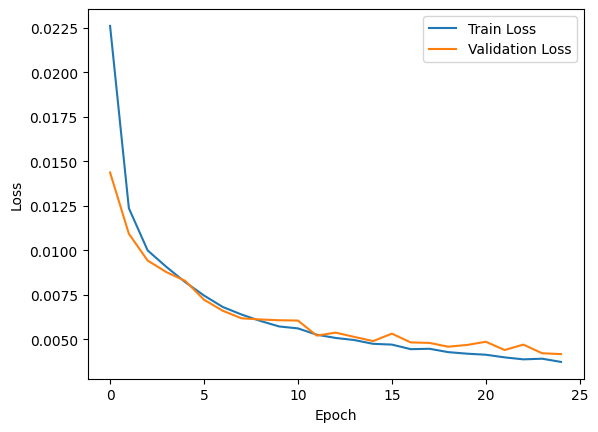

In [43]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [44]:
print(history.history['loss'])
print(history.history['val_loss'])

[0.02259743958711624, 0.012357626110315323, 0.00998535193502903, 0.009057197719812393, 0.008204142563045025, 0.007452046032994986, 0.0068088010884821415, 0.006383456755429506, 0.006024764385074377, 0.005713724996894598, 0.005605778656899929, 0.0052511426620185375, 0.005069884005934, 0.0049505834467709064, 0.004738908726722002, 0.004695041570812464, 0.004438844975084066, 0.0044599114917218685, 0.004272029735147953, 0.0041849552653729916, 0.004125987645238638, 0.003977399785071611, 0.00386660429649055, 0.0039025372825562954, 0.003721946617588401]
[0.014364517293870449, 0.010921485722064972, 0.00941575225442648, 0.008766008540987968, 0.008275003172457218, 0.007219488732516766, 0.006595406215637922, 0.006171624641865492, 0.006105775013566017, 0.006063127890229225, 0.006045709829777479, 0.005199757870286703, 0.005367138423025608, 0.005127925891429186, 0.004892077762633562, 0.0053109279833734035, 0.0048182024620473385, 0.0047900136560201645, 0.004577031824737787, 0.004674724768847227, 0.0048